# Анализ сигналов

Выполнено командой STEAM in DREAM

Cостав: Майоров Александр, Двояшов Владимир, Комиссаров Владимир, Хабарова София, Александрова Ольга

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x = pd.read_csv('data_4W_sem.csv', header=None).to_numpy()
x = x - x[:, :50].mean(axis=1)[:, None]

a = x.max(axis=1)
p = x.argmax(axis=1)

print(x.shape)

(3000, 500)


## Задание 1

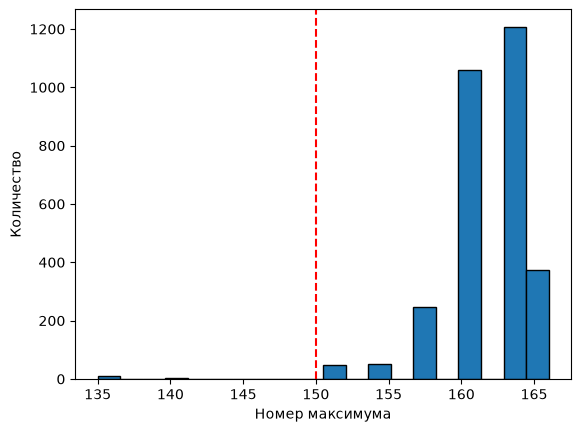

Выбросы: [   2   16  375  388  396  691  859 1574 1580 2079 2211 2617 2628]


In [3]:
plt.hist(p, bins=20, edgecolor='black')
plt.axvline(150, color='red', linestyle='--')
plt.xlabel('Номер максимума')
plt.ylabel('Количество')
plt.show()

bad = p < 150
nums = np.where(bad)[0]
print('Выбросы:', nums)

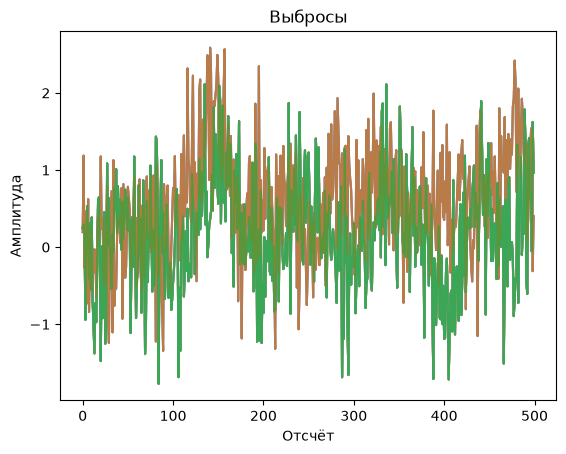

In [4]:
for i in nums:
    plt.plot(x[i], alpha=0.6)

plt.xlabel('Отсчёт')
plt.ylabel('Амплитуда')
plt.title('Выбросы')
plt.show()

## Задание 2

Амплитуда: 163.4
Сигналов: 32


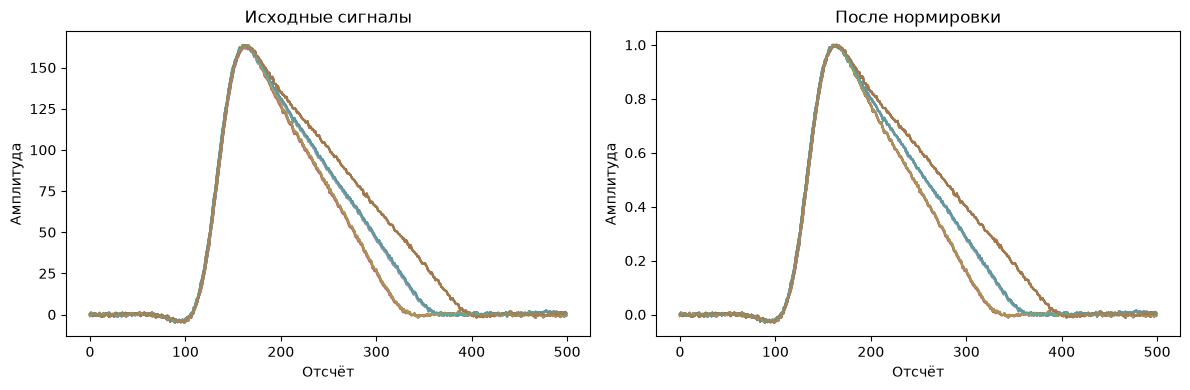

In [5]:
i0 = np.where(~bad)[0][0]
a0 = a[i0]
near = (~bad) & (np.abs(a - a0) <= a0 * 0.005)
nums = np.where(near)[0]

print('Амплитуда:', round(a0, 2))
print('Сигналов:', len(nums))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i in nums:
    ax[0].plot(x[i], alpha=0.5)
    ax[1].plot(x[i] / a[i], alpha=0.5)

ax[0].set_title('Исходные сигналы')
ax[1].set_title('После нормировки')
for q in ax:
    q.set_xlabel('Отсчёт')
    q.set_ylabel('Амплитуда')
plt.tight_layout()
plt.show()

## Задание 3

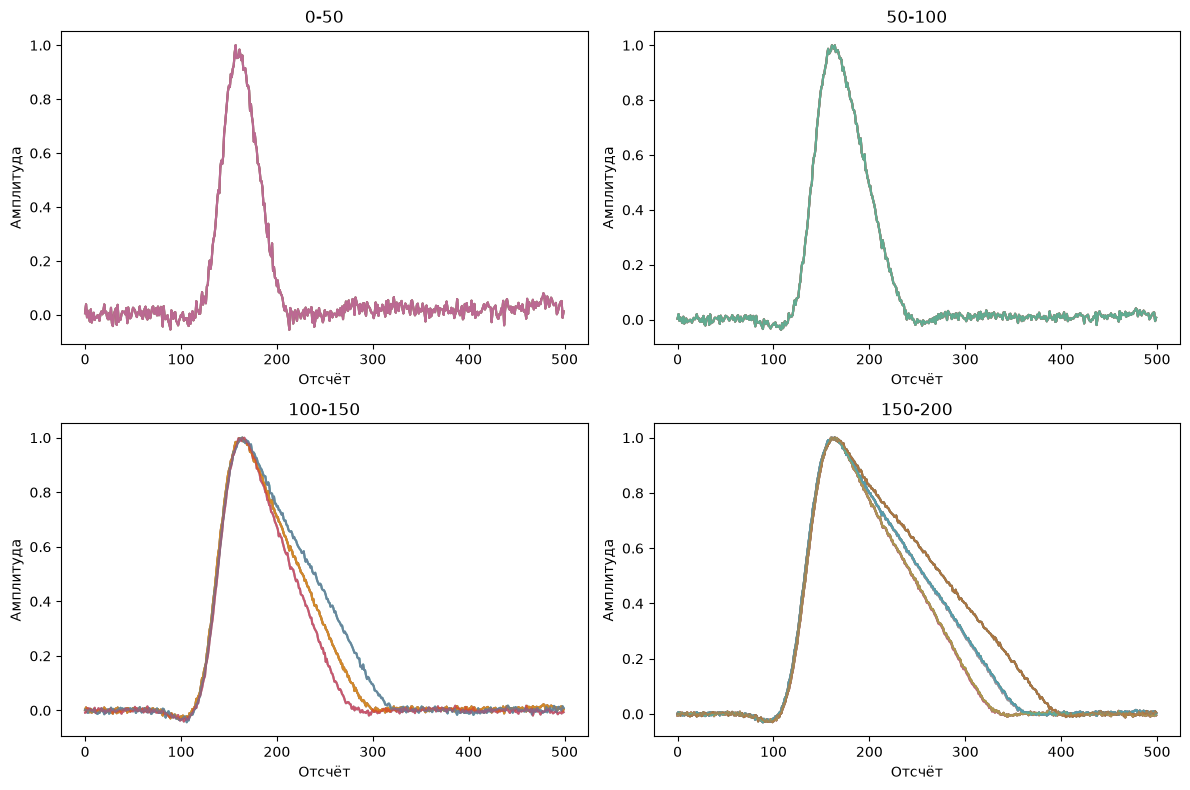

,Диапазон,Амплитуда,Сигналов
0,0-50,30.05,7
1,50-100,58.76,10
2,100-150,107.20,15
3,150-200,163.40,32


In [6]:
r = [(0, 50), (50, 100), (100, 150), (150, 200)]
ans = []
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

for q, (left, right) in zip(ax.ravel(), r):
    part = (~bad) & (a >= left) & (a < right)
    nums = np.where(part)[0]
    i0 = nums[0]
    a0 = a[i0]
    nums = nums[np.abs(a[nums] - a0) <= a0 * 0.005]

    for i in nums:
        q.plot(x[i] / a[i], alpha=0.5)

    q.set_title(f'{left}-{right}')
    q.set_xlabel('Отсчёт')
    q.set_ylabel('Амплитуда')
    ans.append([f'{left}-{right}', round(a0, 2), len(nums)])

plt.tight_layout()
plt.show()

pd.DataFrame(ans, columns=['Диапазон', 'Амплитуда', 'Сигналов'])

Выбросы имеют ранний максимум. Сигналы с близкой амплитудой имеют похожую форму.